In [1]:
import requests
import pandas as pd
import scipy.stats as sps

In [42]:
df = pd.read_csv('../../../../projects/sg-public-data/data/datasets.csv', index_col=['datasetId'])
df.loc[df['name'].str.contains(r'(?i:marriage)')&df['name'].str.contains(r'\b(?i:qual)')&(~df['name'].str.contains(r'\b(?i:muslim)')),'name'].to_dict()

{'d_235cda81c98c02c8fe2e6d86dab461f0': "Marriages Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual",
 'd_988d10c7d86fd052fd28f286d9454eed': "Median Age At First Marriage Of Grooms And Brides Married Under The Women's Charter By Educational Qualification, Annual",
 'd_f9cc6b55334da7fba42dc0e2a7be6aee': "First Marriages For Couples Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual",
 'd_e1149657519492ba9928a7afb27d442e': 'Median Age At First Marriage Of Grooms And Brides By Educational Qualification, Annual',
 'd_a972c0c752ca2aab0d1bd6466cde9149': "Inter-Ethnic Marriages Under The Women's Charter By Educational Qualification Of Grooms And Brides, Annual"}

In [73]:
df = pd.read_csv('../../../../projects/sg-public-data/data/datasets.csv', index_col=['datasetId'])
df.loc[df['name'].str.contains(r'(?i:\bage.*\bqual|\bqual.*\bage)')&df['name'].str.contains(r'(?i:\bannual)'),'name'].to_dict()

{'d_4e41f7ba4593b8eeaa5c5b6d0d42c5ca': 'Marriages Under The Administration Of Muslim Law Act By Age Group And Educational Qualification Of Grooms And Brides, Annual',
 'd_aff1b83ba568b0469ebdcc126412e59a': 'Marriages Under The Administration Of Muslim Law Act By Age Group And Educational Qualification Of Resident Grooms And Brides, Annual',
 'd_97dacc33031cebca70932e3a53a807bf': 'Median Age At First Marriage Of Grooms And Brides Married Under The Administration Of Muslim Law Act By Educational Qualification, Annual',
 'd_988d10c7d86fd052fd28f286d9454eed': "Median Age At First Marriage Of Grooms And Brides Married Under The Women's Charter By Educational Qualification, Annual",
 'd_f4bdb04713874eba07d86c014d29f5f7': 'Average Number Of Children Born To Resident Ever-Married Females Aged 40-49 Years By Highest Qualification Attained, Annual',
 'd_e1149657519492ba9928a7afb27d442e': 'Median Age At First Marriage Of Grooms And Brides By Educational Qualification, Annual',
 'd_504d991189c4cd8

In [74]:
resp = requests.get('https://data.gov.sg/api/action/datastore_search', params={'resource_id': 'd_504d991189c4cd84689f7da9abc63a5a', 'limit': 1024})
if resp.status_code == 200:
    print(resp.json())

{'help': 'https://data.gov.sg/api/3/action/help_show?name=datastore_search', 'success': True, 'result': {'resource_id': 'd_504d991189c4cd84689f7da9abc63a5a', 'fields': [{'type': 'text', 'id': 'DataSeries'}, {'type': 'numeric', 'id': '2023'}, {'type': 'numeric', 'id': '2022'}, {'type': 'numeric', 'id': '2021'}, {'type': 'numeric', 'id': '2020'}, {'type': 'numeric', 'id': '2019'}, {'type': 'numeric', 'id': '2018'}, {'type': 'numeric', 'id': '2017'}, {'type': 'numeric', 'id': '2016'}, {'type': 'numeric', 'id': '2015'}, {'type': 'numeric', 'id': '2014'}, {'type': 'numeric', 'id': '2013'}, {'type': 'numeric', 'id': '2012'}, {'type': 'numeric', 'id': '2011'}, {'type': 'numeric', 'id': '2010'}, {'type': 'numeric', 'id': '2009'}, {'type': 'numeric', 'id': '2008'}, {'type': 'numeric', 'id': '2007'}, {'type': 'numeric', 'id': '2006'}, {'type': 'numeric', 'id': '2005'}, {'type': 'numeric', 'id': '2004'}, {'type': 'numeric', 'id': '2003'}, {'type': 'numeric', 'id': '2002'}, {'type': 'numeric', 'id

In [90]:
df = pd.DataFrame.from_dict(resp.json()['result']['records'])
df = df.loc[df['_id'].gt(70)]
df = df.loc[~df['_id'].between(121, 130)]
df[['Sex', 'Qualification']] = df['DataSeries'].str.extract(r'(?i:total\W+(\w+)\W+(.+))', expand=True).ffill()
df = df.loc[~df['DataSeries'].str.contains(r'(?i:total)'),:]
df.head(40)

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2018,2019,2020,2021,2022,2023,_id,DataSeries,Sex,Qualification
71,60400,56800,52300,46400,41200,28600,24300,22600,21900,18700,...,3900,4100,3900,2500,2000,3100,72,25 - 29 Years,Males,Below Secondary
72,71500,65100,63500,58700,57600,49500,52100,47700,41800,39200,...,3400,4400,4800,3900,4000,4500,73,30 - 34 Years,Males,Below Secondary
73,67400,68500,66200,68200,66800,60400,67200,60900,56000,58000,...,6300,6200,6000,5800,5500,4800,74,35 - 39 Years,Males,Below Secondary
74,60500,61500,61000,63400,63700,58900,65900,70100,68500,69400,...,11900,8300,8800,7900,7700,6200,75,40 - 44 Years,Males,Below Secondary
75,43200,42300,46900,52500,54800,54000,64500,64800,62000,64200,...,16300,17100,15500,11400,11400,11500,76,45 - 49 Years,Males,Below Secondary
76,44200,47800,48600,47300,46300,40600,41600,48700,48700,55100,...,38400,32500,27800,19200,17100,17500,77,50 - 54 Years,Males,Below Secondary
77,41500,42700,42200,41100,42000,40900,43500,45400,45600,42800,...,47700,51200,48700,38400,40100,35600,78,55 - 59 Years,Males,Below Secondary
78,36500,38900,38100,38200,38100,37600,37200,39300,38200,40600,...,56200,54300,55800,51500,49400,44100,79,60 - 64 Years,Males,Below Secondary
79,66600,62400,66200,70800,69800,75300,78600,78400,86100,87500,...,136000,141200,153000,140500,139300,153800,80,65 Years & Over,Males,Below Secondary
81,50100,41200,37300,34200,34900,34800,33600,34000,30000,31600,...,10600,9700,8500,8900,6000,8400,82,25 - 29 Years,Males,Secondary


In [53]:
resp = requests.get('https://data.gov.sg/api/action/datastore_search', params={'resource_id': 'd_235cda81c98c02c8fe2e6d86dab461f0', 'limit': 1024})
if resp.status_code == 200:
    print(resp.json())

{'help': 'https://data.gov.sg/api/3/action/help_show?name=datastore_search', 'success': True, 'result': {'resource_id': 'd_235cda81c98c02c8fe2e6d86dab461f0', 'fields': [{'type': 'text', 'id': 'DataSeries'}, {'type': 'numeric', 'id': '2022'}, {'type': 'numeric', 'id': '2021'}, {'type': 'numeric', 'id': '2020'}, {'type': 'numeric', 'id': '2019'}, {'type': 'numeric', 'id': '2018'}, {'type': 'numeric', 'id': '2017'}, {'type': 'numeric', 'id': '2016'}, {'type': 'numeric', 'id': '2015'}, {'type': 'numeric', 'id': '2014'}, {'type': 'numeric', 'id': '2013'}, {'type': 'numeric', 'id': '2012'}, {'type': 'numeric', 'id': '2011'}, {'type': 'numeric', 'id': '2010'}, {'type': 'numeric', 'id': '2009'}, {'type': 'numeric', 'id': '2008'}, {'type': 'numeric', 'id': '2007'}, {'type': 'numeric', 'id': '2006'}, {'type': 'numeric', 'id': '2005'}, {'type': 'numeric', 'id': '2004'}, {'type': 'numeric', 'id': '2003'}, {'type': 'numeric', 'id': '2002'}, {'type': 'numeric', 'id': '2001'}, {'type': 'numeric', 'id

In [54]:
df = pd.DataFrame.from_dict(resp.json()['result']['records'])
df = df.loc[df['_id'].astype(int).gt(4)]
df['Brides'] = df['DataSeries'].str.extract(r'(?i:brides?\W+\b(.+)\b)', expand=True).ffill()
df['Grooms'] = df['DataSeries'].str.extract(r'(?i:grooms?\W+\b(.+)\b)', expand=True)
df = df.loc[df['Grooms'].notna()]
df = df.drop(columns=['_id', 'DataSeries'])
df['Brides'] = pd.Categorical(df['Brides'], categories=df['Brides'].unique().tolist(), ordered=True)
df['Grooms'] = pd.Categorical(df['Grooms'], categories=df['Grooms'].unique().tolist(), ordered=True)
df = df.set_index(keys=['Brides', 'Grooms'], append=False)
df = df.rename_axis(columns='Year')
df = df.transpose().rename(index=int)
df = df.apply(pd.to_numeric, downcast='integer', axis=1)
df

Brides Secondary & Below                              Post-Secondary  \
Grooms Secondary & Below Post-Secondary University Secondary & Below   
Year                                                                   
1984               14137           1966        561               865   
1985               12887           1809        533               832   
1986               10545           1484        407               688   
1987               12473           1880        537               902   
1988               12709           2087        588              1011   
1989               11710           1950        569               973   
1990               11544           2109        634              1050   
1991               11393           2170        657              1269   
1992               11574           2358        661              1386   
1993               10702           2273        681              1594   
1994                9903           2234        648              1715   
1995                9200           2145        696              1853   
1996                8503           1990        623              1778   
1997                8433           2072        709              1916   
1998                7260           1771        664              1706   
1999                7547           1850        675              1987   
2000                6001           1441        611              1607   
2001                5702           1435        625              1629   
2002                5101           1386        702              1701   
2003                4277           1192        587              1554   
2004                4105           1348        573              1272   
2005                4494           1493        602              1438   
2006                4086           1500        558              1408   
2007                3812           1329        598              1353   
2008                3656           1420        572              1189   
2009                3643           1535        624              1296   
2010                3228           1277        611               982   
2011                3391           1327        670              1117   
2012                3353           1355        593              1094   
2013                2469           1159        622               963   
2014                2402           1196        627               974   
2015                2113           1160        505              1024   
2016                1954           1122        427              1008   
2017                1704            966        431               880   
2018                1515            893        422               798   
2019                1406            831        381               795   
2020                 958            575        276               650   
2021                1325            737        314               798   
2022                1467            748        392               876   

Brides                                  University                            
Grooms Post-Secondary University Secondary & Below Post-Secondary University  
Year                                                                          
1984             1015        468                72            145        743  
1985              946        435                81            154        818  
1986              804        413                85            133        816  
1987             1002        531               103            203       1004  
1988             1255        542               134            246       1210  
1989             1184        564               133            264       1199  
1990             1323        670               173            279       1409  
1991             1628        688               203            323       1654  
1992             1875        774               209            359       1829  
1993             1857      

<Axes: xlabel='Year'>

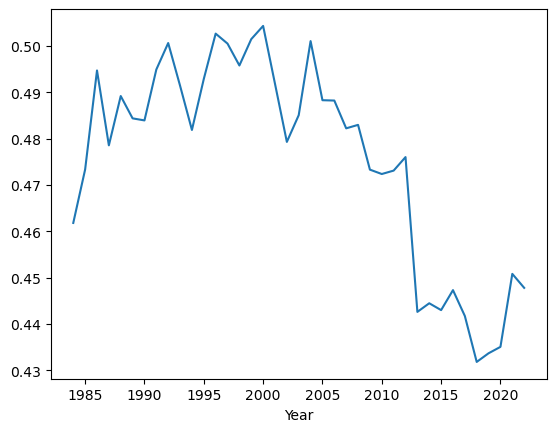

In [5]:
df.apply(
    lambda row: sps.contingency.association(row.unstack(level='Brides').to_numpy()), 
    axis=1
).plot(kind='line')

<Axes: xlabel='Year'>

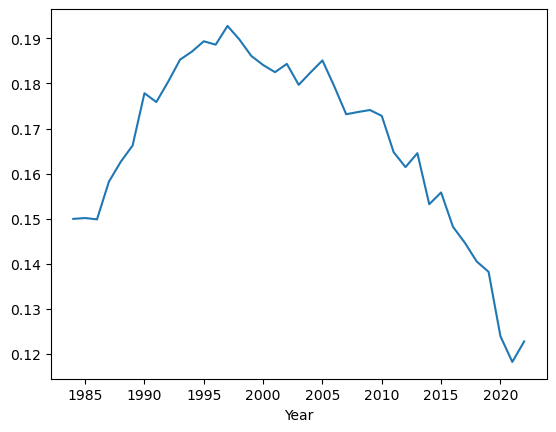

In [6]:
df.apply(
    lambda row: row.loc[row.index.get_level_values(0)<row.index.get_level_values(1)].sum() / row.sum(), 
    axis=1
).plot(kind='line')

In [7]:
resp = requests.get('https://data.gov.sg/api/action/datastore_search', params={'resource_id': 'd_4a6347a51983571d5a5ccfda425266ed', 'limit': 1024})
if resp.status_code == 200:
    print(resp.json())

{'help': 'https://data.gov.sg/api/3/action/help_show?name=datastore_search', 'success': True, 'result': {'resource_id': 'd_4a6347a51983571d5a5ccfda425266ed', 'fields': [{'type': 'text', 'id': 'DataSeries'}, {'type': 'numeric', 'id': '2022'}, {'type': 'numeric', 'id': '2021'}, {'type': 'numeric', 'id': '2020'}, {'type': 'numeric', 'id': '2019'}, {'type': 'numeric', 'id': '2018'}, {'type': 'numeric', 'id': '2017'}, {'type': 'numeric', 'id': '2016'}, {'type': 'numeric', 'id': '2015'}, {'type': 'numeric', 'id': '2014'}, {'type': 'numeric', 'id': '2013'}, {'type': 'numeric', 'id': '2012'}, {'type': 'numeric', 'id': '2011'}, {'type': 'numeric', 'id': '2010'}, {'type': 'numeric', 'id': '2009'}, {'type': 'numeric', 'id': '2008'}, {'type': 'numeric', 'id': '2007'}, {'type': 'numeric', 'id': '2006'}, {'type': 'numeric', 'id': '2005'}, {'type': 'numeric', 'id': '2004'}, {'type': 'numeric', 'id': '2003'}, {'type': 'numeric', 'id': '2002'}, {'type': 'numeric', 'id': '2001'}, {'type': 'numeric', 'id

In [8]:
df = pd.DataFrame.from_dict(resp.json()['result']['records'])
df = df.loc[df['_id'].astype(int).gt(22)]
df['Brides'] = df['DataSeries'].str.extract(r'(?i:brides?\W+aged?\W+\b(.+)\b)', expand=True).ffill()
df['Grooms'] = df['DataSeries'].str.extract(r'(?i:grooms?\W+aged?\W+\b(.+)\b)', expand=True)
df = df.loc[df['Grooms'].notna()]
df = df.drop(columns=['_id', 'DataSeries'])
df['Brides'] = pd.Categorical(df['Brides'], categories=df['Brides'].unique().tolist(), ordered=True)
df['Grooms'] = pd.Categorical(df['Grooms'], categories=df['Grooms'].unique().tolist(), ordered=True)
df = df.set_index(keys=['Brides', 'Grooms'], append=False)
df = df.rename_axis(columns='Year')
df = df.transpose().rename(index=int)
df = df.apply(pd.to_numeric, downcast='integer', axis=1)
df

Brides    20-24 Years                                                  \
Grooms Under 20 Years 20-24 Years 25-29 Years 30-34 Years 35-39 Years   
Year                                                                    
1983               29        3148        4175         820         110   
1984               32        3322        4980         976         118   
1985               17        3122        4447         892         119   
1986               15        2418        3461         781         110   
1987               17        2592        4110         911         131   
1988               18        2727        4380        1019         170   
1989               13        2451        3755        1000         158   
1990               12        2159        3762         978         201   
1991               18        2234        3873        1107         163   
1992               16        2028        4066        1182         229   
1993               27        1912        3838        1269         233   
1994               21        1970        3619        1232         309   
1995               15        1962        3586        1276         296   
1996               21        1738        3202        1190         313   
1997               14        2132        3553        1066         306   
1998               14        1535        2986         902         280   
1999               24        1749        3331         843         295   
2000               17        1311        2586         780         285   
2001               24        1195        2539         789         301   
2002               12        1227        2516         817         281   
2003               10         981        2104         712         245   
2004               11         958        1872         727         279   
2005               10         892        1724         707         305   
2006               18         889        1690         726         293   
2007                9         804        1568         577         298   
2008               18         768        1448         651         277   
2009               15         794        1603         596         315   
2010               10         682        1273         532         272   
2011               13         760        1315         598         280   
2012               10         820        1388         605         248   
2013               13         681        1107         569         235   
2014               16         626        1159         466         197   
2015               11         545        1095         414         194   
2016                7         462        1042         379         141   
2017                5         459         946         290         133   
2018                9         432         890         283         100   
2019               11         342         767         225          95   
2020                7         324         619         205          50   
2021                3         372         710         228          54   
2022                3         306         645         207          56   

Brides                                                                  ...  \
Grooms 40-44 Years 45-49 Years 50-54 Years 55-59 Years 60 Years & Over  ...   
Year                                                                    ...   
1983            26           7           3           1               1  ...   
1984            14           4           3           2               2  ...   
1985            18           5           2           1               0  ...   
1986            16           3           4           0               0  ...   
1987            29           6           3           1               1  ...   
1988            20           3           2           2               0  ...   
1989            26           9           1           1               0  ...   
1990            40           6           2           0               0

<Axes: xlabel='Year'>

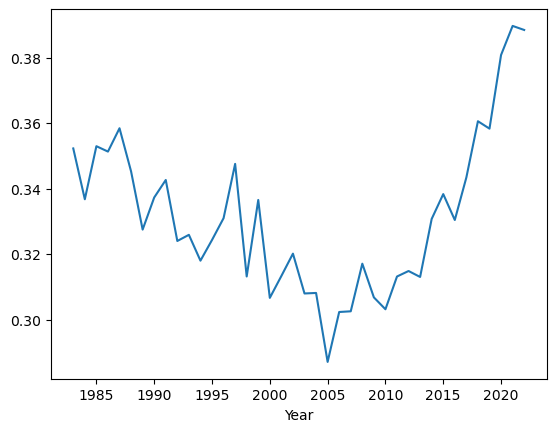

In [9]:
df.apply(
    lambda row: sps.contingency.association(row.unstack(level='Brides').to_numpy()), 
    axis=1
).plot(kind='line')